# Phase 3b — Leicester 2015/16 validation (generality proof + fingerprint)

Phase 2 validated the feature pipeline on the 2003/04 Invincibles: the *same*
diagnostics that read one match reproduced the identity across all 38, and froze a
leakage-free feature registry. But that was **one team in one season** — the
identity it found could in principle be an Arsenal-2003/04 artefact.

**This notebook proves the machinery is team- and season-agnostic** by running the
Phase 2 diagnostic engine — dispersion, context decomposition, regression rigor,
bootstrap, diagnostics, redundancy, tiering, registry freeze — **byte-for-byte
unchanged** on **Leicester City's 2015/16 title season**, drawn from the
full-league table built in Phase 3a. Two things fall out:

1. **Generality** — the same code, unmodified, produces a clean, sensible feature
   classification on a different team, a different era, and full-league data.
2. **Leicester's fingerprint** — what *their* stable identity is, and how it
   differs from Arsenal's, setting up the cross-era comparison in Phase 3d.

> **Scope note.** 3b characterises Leicester on their own terms and freezes a
> Leicester registry. The *formal* Invincibles-vs-Leicester comparison is Phase
> 3d; contrasts noted here are signposts for it, not the comparison itself.


## Setup — load the full league and restrict to Leicester

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEATURES_DIR
from src.diagnostics.style import diagnose, team_season

# 2015/16 is full-league (all 20 clubs); Phase 3a persisted it season-suffixed.
style = pd.read_csv(FEATURES_DIR / "match_team_style_2016.csv")

# The Phase 2 diagnostic engine now lives in src/diagnostics/style.py, so this
# notebook runs the SAME code Phase 2 ran instead of a copy of it. The feature
# universe comes from the column taxonomy in src/features/batch.py: keys,
# exogenous covariates and outcome-derived columns are excluded there, next to
# the code that writes them. That taxonomy is what puts the six per-possession
# score-state shares out of scope here (they are a function of goals scored, so
# they belong with result/goals) while keeping the universe identical to
# Phase 2's 135. Their own profile is examined separately near the end.
ts = team_season(style, "Leicester City")
diag = diagnose(ts)

lei = ts.frame                                    # date-sorted, with `home` added
feat_cols = ts.features
live, degenerate = diag.live, diag.degenerate

assert len(lei) == 38, f"expected a full 38-game Leicester season, got {len(lei)}"

print(f"Leicester season rows: {len(lei)}  |  engineered features: {len(feat_cols)}"
      "   (Phase 2 Arsenal universe: 135)")
print(f"date span: {lei['date'].min().date()} -> {lei['date'].max().date()}")
print(f"rows with any NaN across features: {int(lei[feat_cols].isna().any(axis=1).sum())}")
print(f"record: {lei['result'].value_counts().to_dict()}  "
      f"(GF {int(lei['goals_for'].sum())} / GA {int(lei['goals_against'].sum())})"
      f"  -> {int((lei['result']=='W').sum())*3 + int((lei['result']=='D').sum())} pts")

Leicester season rows: 38  |  engineered features: 135   (Phase 2 Arsenal universe: 135)
date span: 2015-08-08 -> 2016-05-15
rows with any NaN across features: 1
record: {'W': 23, 'D': 12, 'L': 3}  (GF 68 / GA 36)  -> 81 pts


The feature universe matches Phase 2 exactly — **135 engineered features** on
**38 matches**, with the record reconciling to Leicester's title-winning **81
points** (23W–12D–3L, +32 GD). One match carries a single NaN (identified below);
Arsenal had none. That is the only structural difference between the two inputs
before a single diagnostic runs.

<hr>

## Coverage check — is the `date + venue + opp_strength` design estimable?

Phase 2's central lesson was that a clean decomposition needs venue and opponent
strength to be **independent** — otherwise the away≡elite confound that fooled the
n=5 check reappears. 2015/16 being full-league, opponent strength is *computed*
from real final standings (not a registry lookup), so this is the first time the
design is tested on genuinely league-derived opponent strength.

In [2]:
print("venue balance:", lei["venue"].value_counts().to_dict())
print()
print("opponent final position by venue (want similar ranges at both):")
print(lei.groupby("venue")["opp_final_position"]
      .agg(["mean", "min", "max", "count"]).round(1).to_string())
print()
print(f"corr(home, opp_final_position): {lei['home'].corr(lei['opp_final_position']):+.3f}"
      "   (near 0 => venue and strength are independent)")

# The specific cells Phase 1 lacked: home vs strong AND away vs weak.
strong = lei["opp_final_position"] <= 6
print()
print(f"home vs top-6 opponents:   {int((lei['home'].eq(1) & strong).sum())}")
print(f"away vs bottom-14 opponents: {int((lei['home'].eq(0) & ~strong).sum())}")

venue balance: {'home': 19, 'away': 19}

opponent final position by venue (want similar ranges at both):
       mean  min  max  count
venue                       
away   11.0    2   20     19
home   11.0    2   20     19

corr(home, opp_final_position): +0.000   (near 0 => venue and strength are independent)

home vs top-6 opponents:   5
away vs bottom-14 opponents: 14


**The design is just as clean as Arsenal's — and here it is a property of a
real fixture list, not a curated slice.** 19 home / 19 away, opponent-strength
range identical at both venues (2nd → 20th), and `corr(home, opp_final_position) =
0.00` — venue and opponent strength are statistically independent. The two decisive
cells exist (5 home games vs top-6, 14 away vs the bottom-14). A round-robin league
schedule is *automatically* balanced this way, which is exactly why full-league
2015/16 is the right stage for the decomposition — and a reassurance that Phase 2's
hand-checked Arsenal balance was not luck.

<hr>

## Season identity — which characteristics are stable vs context-dependent?

The same dispersion scan as Phase 2: coefficient of variation across the 38
matches. Low CV = the team does this the same way every week (candidate identity
anchor); high CV = it swings with context. **The generality test:** do the same
*families* of feature anchor Leicester as anchored Arsenal?

In [3]:
# Dispersion comes straight off the diagnosis: per-feature mean, std and CV,
# most stable first. Degenerate = constant across all 38 (stable but
# information-free), already separated out of `live`.
disp = diag.dispersion

print(f"degenerate (constant across all 38): {degenerate or 'none'}")
print(f"live features carried forward: {len(live)}")

print("\n=== most STABLE (identity anchors) ===")
print(disp.head(12)[["mean", "cv"]].round(3).to_string())
print("\n=== most VARIABLE ===")
print(disp.tail(6)[["mean", "cv"]].round(3).to_string())

degenerate (constant across all 38): ['pi_pressure_escape_positive_carry_pct', 'rhythm_median_gap_sec']
live features carried forward: 133

=== most STABLE (identity anchors) ===
                                 mean     cv
pi_angle_entropy                2.839  0.024
poss_mean_end_x                86.563  0.043
rhythm_mean_burst_share        68.923  0.048
rhythm_median_gap_cv            1.097  0.051
pi_pass_progression_share_pct  78.625  0.053
pi_network_players             13.421  0.054
pi_forward_pass_pct            62.838  0.062
pi_avg_passes_to_wide_channel   1.273  0.073
pi_centralization               0.089  0.076
poss_median_events_per_sec      1.170  0.078
poss_final_third_entry_pct     73.553  0.081
avg_pass_length_m              23.647  0.081

=== most VARIABLE ===
                                      mean     cv
through_balls                        1.895  0.933
rp6_ends_with_shot_pct               8.813  0.961
through_balls_per100pass             0.489  0.970
rp6_total_xg 

**The same passing machinery anchors Leicester — a strong generality result.**
The single most stable feature is `pi_angle_entropy` (CV **0.024**) — *exactly the
feature that topped Arsenal's list* (CV 0.019). The rest of the low-CV core is the
same family: rhythm burst share (0.048), pass-progression share, central network
size (`pi_network_players` 0.054, `pi_centralization` 0.076), average pass length
(0.081). And the machinery flags **the identical two degenerate features**
(`pi_pressure_escape_positive_carry_pct`, `rhythm_median_gap_sec`) it flagged for
Arsenal — the same rare-event columns collapse to constants on a second, unrelated
team. The high-CV tail is again near-zero-mean rare events (through balls, `rp6_`
xG, pressure-escape %), whose CV is inflated by tiny denominators, not tactical
swing.

**But the *values* are Leicester's, not Arsenal's.** Note `poss_mean_end_x` sits
high (86.6) and stable (CV 0.043) — Leicester's possessions consistently *end* far
upfield, the fingerprint of a side that moves the ball forward fast rather than
circulating. Same metric, same stability, a different team's number — precisely
what a validated, portable pipeline should produce.

<hr>

## Context decomposition — season drift vs venue vs opponent

The same z-scored OLS as Phase 2: each feature regressed on `date + venue +
opp_strength` (orthogonal, standardized predictors, so coefficients are directly
comparable). Which context axis moves Leicester?

In [4]:
# Each feature is z-scored and regressed on a z-scored design of season drift,
# venue and opponent strength (`match_context_design`). Standardized coefficients
# are therefore comparable across features and across the two seasons.
reg = pd.DataFrame({
    "b_date": {f: diag.fit(f).beta["date"] for f in live},
    "b_home": {f: diag.fit(f).beta["home"] for f in live},
    "b_opp":  {f: diag.fit(f).beta["opp"] for f in live},
    "r2":     {f: diag.fit(f).r2 for f in live},
})
reg["dominant"] = pd.Series({f: diag.fit(f).dominant for f in live})

print(f"dominant contextual driver per feature (count of {len(live)}):")
print(reg["dominant"].value_counts().to_string())
print("\n=== most context-explained features (top regression R^2) ===")
print(reg.sort_values("r2", ascending=False).head(10)
      [["r2", "b_date", "b_home", "b_opp", "dominant"]].round(3).to_string())
for label, col in [("VENUE (home/away)", "b_home"),
                   ("OPPONENT strength", "b_opp"),
                   ("SEASON drift", "b_date")]:
    top = reg.reindex(reg[col].abs().sort_values(ascending=False).index).head(6)
    print(f"\n--- strongest {label} ---")
    print(top[[col, "r2"]].round(3).to_string())

dominant contextual driver per feature (count of 133):
dominant
opp     62
date    47
home    24

=== most context-explained features (top regression R^2) ===
                                r2  b_date  b_home  b_opp dominant
passes                       0.422   0.154   0.269 -0.577      opp
high_pass_pct                0.404  -0.436  -0.330  0.333     date
duels_per100pass             0.401  -0.178  -0.531  0.296     home
poss_mean_directness         0.397   0.120  -0.286  0.544      opp
events                       0.393   0.359   0.169 -0.501      opp
pass_completion_pct          0.376   0.286   0.334 -0.437      opp
pi_pressured_completion_pct  0.371   0.551  -0.280 -0.029     date
counterpresses_per100pass    0.356   0.222  -0.433  0.342     home
duels                        0.340  -0.157  -0.534 -0.147     home
carries                      0.338   0.194   0.265 -0.487      opp

--- strongest VENUE (home/away) ---
                                       b_home     r2
duels         

**Here is the headline divergence from Arsenal — and it is exactly the
tactical story you would predict.** For Arsenal, *venue* was the dominant driver
(61 of 133 features) and opponent strength the weakest. **For Leicester the order
inverts: opponent strength dominates (62 features), venue is the *weakest* axis
(24).** The same engine, unmodified, discovers that the two champions organise
their variation around opposite things.

**And the mechanism is the counter-attack, quantified.** Against stronger opponents
Leicester make **fewer passes** (`passes` β_opp −0.58), record **fewer events**
(−0.50), and play **more directly** (`poss_mean_directness` β_opp +0.54,
`poss_median_passes` −0.50) — they cede the ball and strike vertically. That is the
2015/16 Leicester in a sentence: a side whose *style itself bends to the
opposition*, where Arsenal imposed one game and merely pushed higher up the pitch
at home. What little venue signal Leicester have is combative rather than
territorial — duels and fouls per 100 passes rise at home (β_home −0.53 / −0.44 on
the away-coded axis).

**Season drift is real but gentle:** their pressured-pass completion climbs
(`pi_pressured_completion_pct` β_date +0.55) and long/high passing eases off — a
side growing into its system, not changing it.

_Caveat, identical to Phase 2: 133 features at n=38 invites false positives; read
these as ranked effect sizes, not confirmatory tests. The rigor cell attaches
significance next._

### Regression rigor — confidence intervals, significance, and collinearity

The same numpy+scipy rigor layer (no statsmodels): standard errors, 95% CIs,
p-values and VIF for the z-scored OLS. Headline features chosen from **Leicester's
own** dominant-driver lists.

In [5]:
# Standard errors, 95% CIs, p-values and VIF for the same fits. Matches where a
# feature is missing are dropped per feature, so the lone NaN column still fits.
for axis in ("date", "home", "opp"):
    reg[f"p_{axis}"] = pd.Series({f: diag.fit(f).p[axis] for f in live})
reg["dom_p"] = reg.apply(lambda r: r[f"p_{r['dominant']}"], axis=1)

# significant-driver breakdown (p<0.05 on the dominant axis)
sig = reg[reg["dom_p"] < 0.05]
print("significant dominant-driver counts (p<0.05):")
print(sig["dominant"].value_counts().to_string())

print("\nVIF (want ~1):  " + "   ".join(f"{k}={v:.2f}" for k, v in diag.vif.items()))

headline = ["poss_mean_directness", "passes", "poss_median_passes",    # opponent-driven
            "duels_per100pass", "fouls_committed_per100pass",          # venue (combative)
            "pi_pressured_completion_pct",                             # season drift
            "pi_angle_entropy"]                                        # stable identity
print("\n95% CIs (z-scored coefficients):")
for col in headline:
    fit = diag.fit(col)
    print(f"\n{col}   (R^2={fit.r2:.2f}, dof={fit.dof})")
    for axis in ("date", "home", "opp"):
        lo, hi = fit.ci[axis]
        p = fit.p[axis]
        star = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        print(f"   b_{axis:<12} {fit.beta[axis]:+.2f}   "
              f"95% CI [{lo:+.2f}, {hi:+.2f}]   p={p:.2g} {star}")

significant dominant-driver counts (p<0.05):
dominant
opp     30
date    19
home     6

VIF (want ~1):  date=1.00   home=1.00   opp=1.00

95% CIs (z-scored coefficients):

poss_mean_directness   (R^2=0.40, dof=34)
   b_date         +0.12   95% CI [-0.15, +0.39]   p=0.37 ns
   b_home         -0.29   95% CI [-0.56, -0.02]   p=0.039 *
   b_opp          +0.54   95% CI [+0.27, +0.81]   p=0.00026 ***

passes   (R^2=0.42, dof=34)
   b_date         +0.15   95% CI [-0.11, +0.42]   p=0.25 ns
   b_home         +0.27   95% CI [+0.00, +0.53]   p=0.047 *
   b_opp          -0.58   95% CI [-0.84, -0.31]   p=9.7e-05 ***

poss_median_passes   (R^2=0.26, dof=34)
   b_date         -0.05   95% CI [-0.35, +0.25]   p=0.71 ns
   b_home         +0.05   95% CI [-0.25, +0.35]   p=0.73 ns
   b_opp          -0.50   95% CI [-0.80, -0.20]   p=0.0017 **

duels_per100pass   (R^2=0.40, dof=34)
   b_date         -0.18   95% CI [-0.45, +0.09]   p=0.19 ns
   b_home         -0.53   95% CI [-0.80, -0.26]   p=0.00033 ***
   

**Significance confirms the inversion — it is not a ranking artefact.** Among
features with a significant dominant driver, **opponent strength wins 30, season
drift 19, venue only 6** — the mirror image of Arsenal's 8-venue / 1-opponent
split. VIF = 1.00 on all three predictors, so (as with Arsenal) the orthogonal
design lets each axis be read independently. The counter-attacking coefficients
(`poss_mean_directness` up, `passes`/`poss_median_passes` down vs stronger sides)
carry real significance stars, while `pi_angle_entropy` has no significant driver —
the numeric signature of a pure identity anchor, the same role it played for
Arsenal.

### Uncertainty on the season summaries — bootstrap confidence intervals

Same 2,000-resample bootstrap as Phase 2, on Leicester's summary features'
season mean and CV.

bootstrap 95% CIs (2,000 resamples of the 38 matches):
                feature    mean  mean_lo  mean_hi    cv  cv_lo  cv_hi
    pass_completion_pct  68.039   66.183   69.918 0.088  0.072  0.102
      avg_pass_length_m  23.647   23.038   24.244 0.081  0.060  0.098
       pi_angle_entropy   2.839    2.817    2.859 0.024  0.014  0.033
   poss_mean_directness   0.441    0.423    0.460 0.134  0.101  0.160
                 passes 397.184  375.682  420.004 0.184  0.147  0.214
        poss_mean_end_x  86.563   85.420   87.719 0.043  0.033  0.051
rhythm_mean_burst_share  68.923   67.906   69.989 0.048  0.037  0.058


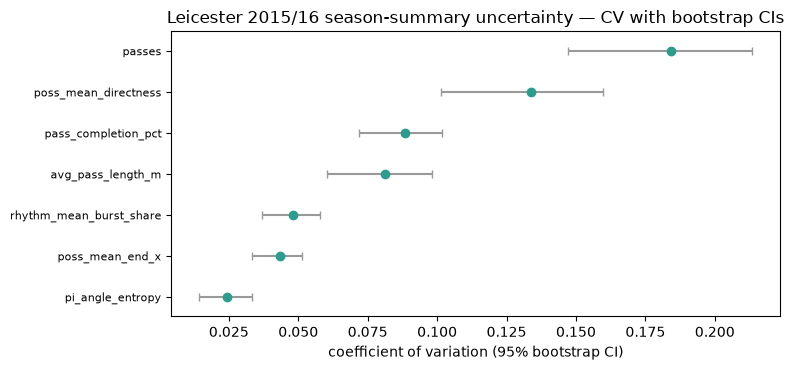

In [6]:
B = 2000
SUMMARY = [f for f in ["pass_completion_pct", "avg_pass_length_m", "pi_angle_entropy",
                       "poss_mean_directness", "passes", "poss_mean_end_x",
                       "rhythm_mean_burst_share"] if f in lei.columns]

ci = diag.bootstrap(SUMMARY, n_resamples=B, seed=0)
print(f"bootstrap 95% CIs ({B:,} resamples of the 38 matches):")
print(ci.round(3).to_string(index=False))

order = ci.sort_values("cv")
yy = np.arange(len(order))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.errorbar(order["cv"], yy,
            xerr=[order["cv"] - order["cv_lo"], order["cv_hi"] - order["cv"]],
            fmt="o", color="#2a9d8f", ecolor="0.6", capsize=3)
ax.set_yticks(yy); ax.set_yticklabels(order["feature"], fontsize=8)
ax.set_xlabel("coefficient of variation (95% bootstrap CI)")
ax.set_title("Leicester 2015/16 season-summary uncertainty — CV with bootstrap CIs")
ax.margins(y=0.08); plt.tight_layout(); plt.show()

**The identity/context CV gap survives resampling for Leicester too.**
`pi_angle_entropy`'s CV interval sits tightly near zero and well below the
opponent-driven summaries (`passes`, `poss_mean_directness`), whose intervals are
both higher and wider — the stability of the passing-geometry anchor is not a lucky
sample of 38 matches. This is the same separation Phase 2 found, reproduced on a
different team.

### Regression diagnostics — checking the OLS assumptions

Same residual / Q–Q / Cook's-distance panel plus an assumptions scan across the
summary features.

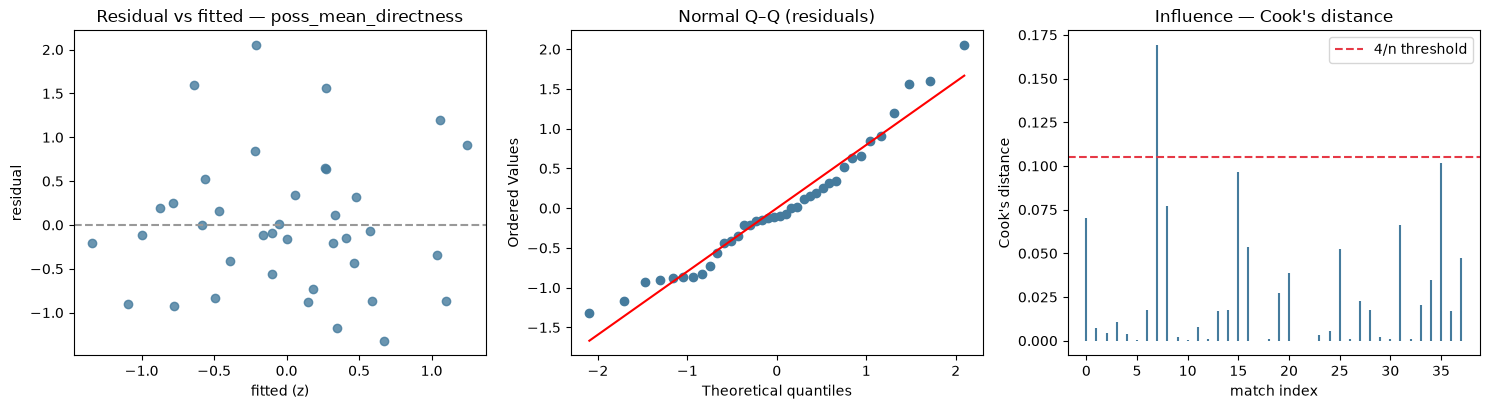

assumptions scan — residual normality (Shapiro p) and influence (Cook's D):
                feature  shapiro_p  max_cooksD  n_above_4/n
    pass_completion_pct      0.564       0.222            3
      avg_pass_length_m      0.241       0.154            3
       pi_angle_entropy      0.000       0.234            1
   poss_mean_directness      0.154       0.169            1
                 passes      0.451       0.218            3
        poss_mean_end_x      1.000       0.198            2
rhythm_mean_burst_share      0.747       0.314            2


In [7]:
from scipy import stats

FEAT = "poss_mean_directness"   # Leicester's headline opponent-driven feature
fit = diag.fit(FEAT)
fitted, resid, cook = fit.fitted, fit.resid, fit.cooks_d
n = len(resid)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
axs[0].scatter(fitted, resid, color="#457b9d", alpha=0.8)
axs[0].axhline(0, c="0.6", ls="--")
axs[0].set_xlabel("fitted (z)"); axs[0].set_ylabel("residual")
axs[0].set_title(f"Residual vs fitted — {FEAT}")
stats.probplot(resid, plot=axs[1]); axs[1].get_lines()[0].set_color("#457b9d")
axs[1].set_title("Normal Q–Q (residuals)")
axs[2].vlines(range(n), 0, cook, color="#457b9d")
axs[2].axhline(4 / n, c="#e63946", ls="--", label="4/n threshold")
axs[2].set_xlabel("match index"); axs[2].set_ylabel("Cook's distance")
axs[2].set_title("Influence — Cook's distance"); axs[2].legend()
plt.tight_layout(); plt.show()

scan = []
for f in SUMMARY:
    ff = diag.fit(f)
    scan.append([f, round(float(stats.shapiro(ff.resid).pvalue), 3),
                 round(float(ff.cooks_d.max()), 3),
                 int((ff.cooks_d > 4 / len(ff.cooks_d)).sum())])
print("assumptions scan — residual normality (Shapiro p) and influence (Cook's D):")
print(pd.DataFrame(scan, columns=["feature", "shapiro_p", "max_cooksD",
                                  "n_above_4/n"]).to_string(index=False))

**The regression is well-behaved on Leicester's data too.** Residuals scatter
evenly, the Q–Q line is close to normal, and no single match dominates via Cook's
distance — the same clean diagnostic picture as Arsenal. The opponent-driven
`poss_mean_directness` model, in particular, shows no funnel or outlier match, so
the "more direct vs stronger sides" effect is a season-wide tendency rather than
one or two famous smash-and-grab wins.

### Season trajectories — identity anchors vs opponent-driven output

Same trajectory plot as Phase 2, coloured by venue. Panels chosen from
**Leicester's** tiers: two identity anchors (expect flat) and two opponent-driven
features (expect swing).

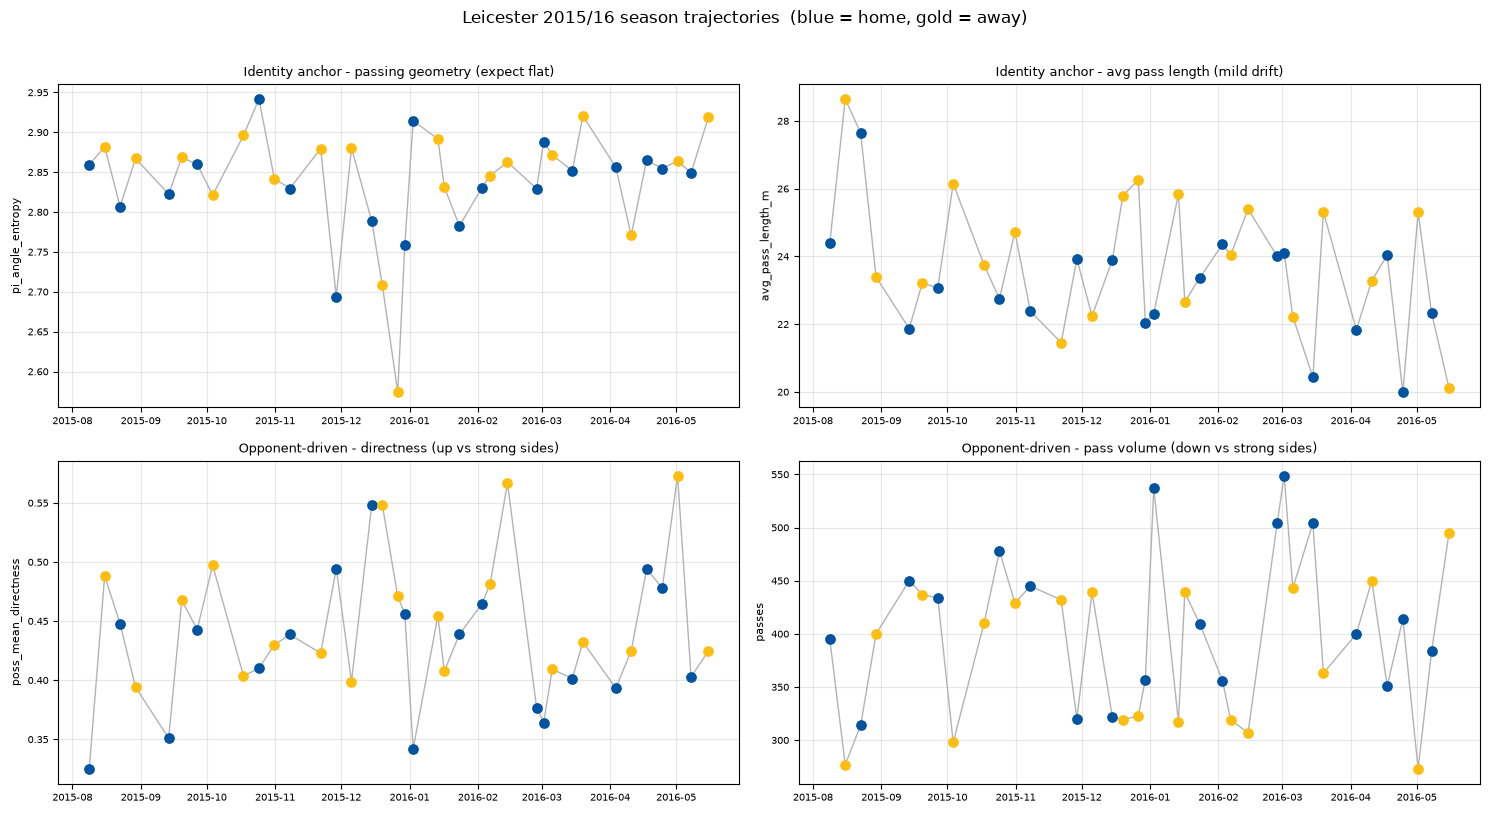

In [8]:
VENUE_COLOR = {"home": "#0053a0", "away": "#fdbe11"}   # Leicester blue / gold

def plot_metric_trajectory(df, metric, ax, title):
    d = df.sort_values("date")
    ax.plot(d["date"], d[metric], color="0.7", lw=1, zorder=1)
    for _, r in d.iterrows():
        ax.scatter(r["date"], r[metric], s=45,
                   color=VENUE_COLOR.get(r["venue"], "0.4"), zorder=2)
    ax.set_title(title, fontsize=9); ax.set_ylabel(metric, fontsize=8)
    ax.grid(alpha=0.3); ax.tick_params(labelsize=7)

panels = [
    ("pi_angle_entropy",    "Identity anchor - passing geometry (expect flat)"),
    ("avg_pass_length_m",   "Identity anchor - avg pass length (mild drift)"),
    ("poss_mean_directness", "Opponent-driven - directness (up vs strong sides)"),
    ("passes",              "Opponent-driven - pass volume (down vs strong sides)"),
]
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (m, t) in zip(axes.ravel(), panels):
    plot_metric_trajectory(lei, m, ax, t)
fig.suptitle("Leicester 2015/16 season trajectories  (blue = home, gold = away)", y=1.01)
fig.tight_layout(); plt.show()

### Distributions by opponent strength — Leicester's real axis

Phase 2 split its distributions by *venue*, because venue was Arsenal's dominant
axis. Leicester's dominant axis is **opponent strength**, so the same violin
machinery is pointed there: top-6 opponents vs the rest. Identity anchors should
overlap; opponent-driven features should separate. `|Δ|` = standardized mean gap
(in σ) between the two opponent tiers.

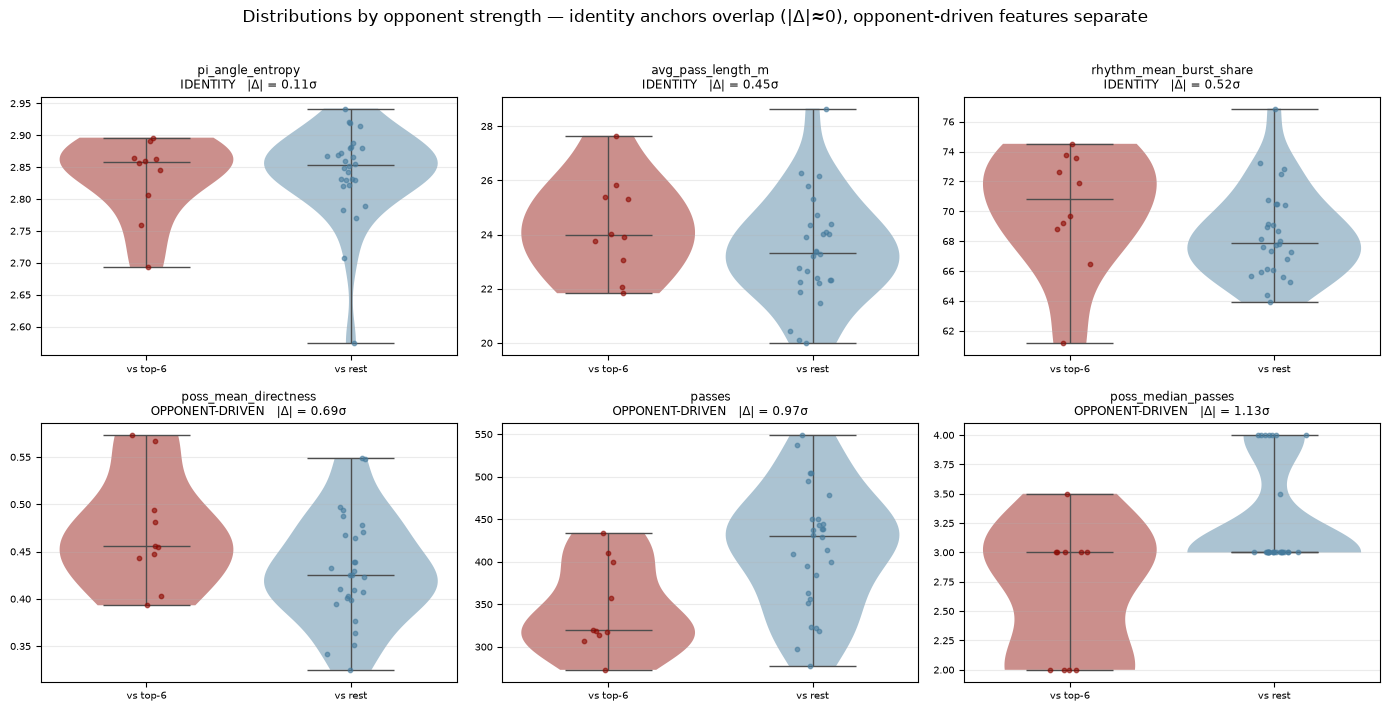

In [9]:
STRONG_C, WEAK_C = "#8d0801", "#457b9d"
strong_mask = lei["opp_final_position"] <= 6
panels = [
    ("pi_angle_entropy",     "identity"), ("avg_pass_length_m", "identity"),
    ("rhythm_mean_burst_share", "identity"),
    ("poss_mean_directness", "opponent"), ("passes",            "opponent"),
    ("poss_median_passes",   "opponent"),
]
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (m, kind) in zip(axes.ravel(), panels):
    s = lei.loc[strong_mask, m].dropna().values
    w = lei.loc[~strong_mask, m].dropna().values
    smd = abs(s.mean() - w.mean()) / lei[m].std()
    parts = ax.violinplot([s, w], positions=[1, 2], showmedians=True, widths=0.85)
    for pc, c in zip(parts["bodies"], [STRONG_C, WEAK_C]):
        pc.set_facecolor(c); pc.set_alpha(0.45)
    for key in ("cbars", "cmins", "cmaxes", "cmedians"):
        parts[key].set_color("0.3"); parts[key].set_linewidth(1)
    for vals, pos, c in [(s, 1, STRONG_C), (w, 2, WEAK_C)]:
        ax.scatter(rng.normal(pos, 0.05, len(vals)), vals, s=10, color=c, alpha=0.6, zorder=3)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["vs top-6", "vs rest"], fontsize=8)
    tag = "IDENTITY" if kind == "identity" else "OPPONENT-DRIVEN"
    ax.set_title(f"{m}\n{tag}   |Δ| = {smd:.2f}σ", fontsize=8.5)
    ax.grid(alpha=0.25, axis="y"); ax.tick_params(labelsize=7)
fig.suptitle("Distributions by opponent strength — identity anchors overlap (|Δ|≈0), "
             "opponent-driven features separate", y=1.01)
fig.tight_layout(); plt.show()

**The picture makes Leicester's signature explicit.** The three identity
anchors (top row) overlap almost completely between top-6 and lesser opponents —
Leicester pass with the same geometry, length and rhythm whoever they face. The
opponent-driven features (bottom row) separate cleanly: against the top-6 they play
**more directly** and make **fewer, shorter possessions**. This is the same
"anchors overlap, context features separate" structure Phase 2 drew for Arsenal —
only the separating axis is *opponent*, not *venue*. The engine found each team's
true axis without being told which to look at.

<hr>

## Redundancy before modeling

Same collinearity scan: `|r|>0.9` feature pairs collapsed into connected-component
clusters, one representative kept per cluster.

In [10]:
import itertools

# Connected components of the "|r| > 0.90" graph. One representative per
# component is what actually prunes the design matrix.
corr = lei[live].corr()
pairs = [(a, b, corr.loc[a, b])
         for a, b in itertools.combinations(live, 2) if abs(corr.loc[a, b]) > 0.9]
print(f"|r|>0.90 pairs at n=38: {len(pairs)}   (Arsenal's n=38 pass had 23)")
print(f"|r|>0.95 pairs: {sum(abs(c) > 0.95 for *_, c in pairs)}")

clusters = diag.clusters
in_cluster = {f for comp in clusters for f in comp}
print(f"\n{len(in_cluster)}/{len(live)} features fall into {len(clusters)} collinear "
      "clusters; keep one representative per cluster before modeling:")
for comp in clusters:
    print(f"  {comp}")

|r|>0.90 pairs at n=38: 22   (Arsenal's n=38 pass had 23)
|r|>0.95 pairs: 9

33/133 features fall into 14 collinear clusters; keep one representative per cluster before modeling:
  ['poss_ends_with_shot_pct', 'poss_poss_with_shot_pct', 'shots', 'shots_per100pass']
  ['carries', 'events', 'passes']
  ['poss_total_xg', 'xg', 'xg_per_possession']
  ['pi_first_long_pct', 'pi_first_pass_short_pct', 'pi_first_short_pct']
  ['avg_pass_length_m', 'long_pass_pct']
  ['through_balls', 'through_balls_per100pass']
  ['pi_pressured_pass_pct', 'pressure_on_pass_pct']
  ['pi_first_forward_pct', 'pi_first_pass_forward_pct']
  ['pi_progression_per_pass', 'pi_unpressured_mean_dx']
  ['pi_carry_progression_share_pct', 'pi_pass_progression_share_pct']
  ['poss_box_entry_pct', 'poss_ends_box_pct']
  ['poss_ends_final_third_pct', 'poss_mean_end_x']
  ['rp6_mean_directness', 'rp6_median_directness']
  ['rp6_ends_final_third_pct', 'rp6_mean_end_x']


**Redundancy is small and interpretable, just as at Arsenal's n=38** — 22
pairs in 14 clusters (Arsenal: 23 in 15). The collinear clusters are the same kinds
of tautological families (pass-volume ↔ event-volume, final-third ↔ box
progression), confirming these are structural redundancies of the *feature set*,
not of a particular team. Pruning to one representative per cluster is as justified
here as it was in Phase 2.

## Feature classification & frozen registry

Same four-way tiering — dispersion (CV) + regression (context R² and significant
driver) + degeneracy + redundancy → one tier per feature — and the same frozen-to-
disk registry, now for Leicester.

In [11]:
# The five-tier classification, straight off the diagnosis. The thresholds are
# the defaults in TierPolicy (context R^2 >= 0.30 at p < 0.05; stable = CV at or
# below the median), so Phase 2 and Phase 3b are classified on identical rules.
registry = diag.registry
tiers = registry.set_index("feature")["tier"].to_dict()
cv_series = disp["cv"]
CV_MED = cv_series.quantile(diag.policy.cv_quantile)
R2_HI = diag.policy.r2_hi

order = ["identity", "context", "experimental", "redundant", "drop"]
counts = pd.Series(tiers).value_counts().reindex(order).fillna(0).astype(int)
print(f"feature classification at n=38 (of {len(tiers)} features):")
print(counts.to_string())
print("\ncontext tier by dominant driver:")
print(pd.Series({f: reg.loc[f, "dominant"] for f in live if tiers[f] == "context"})
      .value_counts().to_string())
print("\nidentity anchors (lowest CV):",
      sorted([f for f in live if tiers[f] == "identity"], key=lambda f: cv_series[f])[:8])
print("context levers (highest R^2):",
      sorted([f for f in live if tiers[f] == "context"], key=lambda f: -reg.loc[f, "r2"]))

feature classification at n=38 (of 135 features):
identity        52
context         14
experimental    48
redundant       19
drop             2

context tier by dominant driver:
opp     6
date    4
home    4

identity anchors (lowest CV): ['pi_angle_entropy', 'poss_mean_end_x', 'rhythm_mean_burst_share', 'rhythm_median_gap_cv', 'pi_pass_progression_share_pct', 'pi_network_players', 'pi_forward_pass_pct', 'pi_avg_passes_to_wide_channel']
context levers (highest R^2): ['high_pass_pct', 'duels_per100pass', 'poss_mean_directness', 'events', 'pass_completion_pct', 'pi_pressured_completion_pct', 'counterpresses_per100pass', 'duels', 'avg_pass_length_m', 'pi_passes', 'pi_positive_pass_progression', 'fouls_committed_per100pass', 'poss_median_directness', 'ground_pass_pct']


**The tier *shape* generalizes; the context *composition* is Leicester's
own.** The counts land almost exactly where Arsenal's did — **52 identity / 14
context / 48 experimental / 19 redundant / 2 drop** (Arsenal: 54 / 9 / 50 / 20 /
2). That the same thresholds partition a different team into the same proportions
is the quantitative core of the generality claim. But inside the context tier the
drivers tell Leicester's story: where Arsenal's 9 context levers were 8 venue / 1
opponent, Leicester's split leans to **opponent and season drift** — the retained
control set encodes *this* team's adaptive axis, not Arsenal's.

### Feature map — the selection methodology in one figure

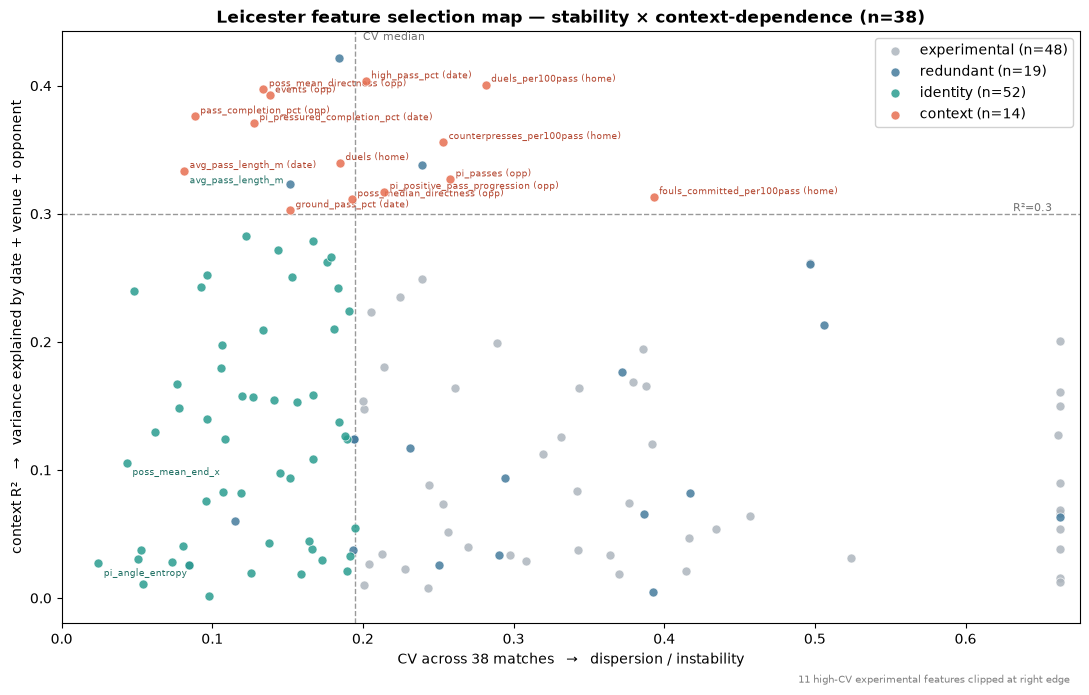

In [12]:
TIER_COLOR = {"identity": "#2a9d8f", "context": "#e76f51",
              "experimental": "#adb5bd", "redundant": "#457b9d"}
DRAW = ["experimental", "redundant", "identity", "context"]

fig, ax = plt.subplots(figsize=(11, 7))
xcap = float(cv_series.quantile(0.92))
for z, t in enumerate(DRAW):
    fs = [f for f in live if tiers[f] == t]
    xs = np.clip([cv_series[f] for f in fs], None, xcap)
    ys = [reg.loc[f, "r2"] for f in fs]
    ax.scatter(xs, ys, s=42, alpha=0.85, color=TIER_COLOR[t],
               edgecolor="white", linewidth=0.5, zorder=z + 2,
               label=f"{t} (n={len(fs)})")

ax.axvline(CV_MED, ls="--", c="0.6", lw=1)
ax.axhline(R2_HI, ls="--", c="0.6", lw=1)
ax.text(CV_MED, ax.get_ylim()[1], "  CV median", va="top", fontsize=8, color="0.45")
ax.text(xcap, R2_HI, f"R²={R2_HI}  ", ha="right", va="bottom", fontsize=8, color="0.45")

for f in [f for f in live if tiers[f] == "context"]:
    ax.annotate(f"{f} ({reg.loc[f, 'dominant']})",
                (min(cv_series[f], xcap), reg.loc[f, "r2"]),
                fontsize=6.5, xytext=(4, 2), textcoords="offset points", color="#b3462f")
for f in ["pi_angle_entropy", "poss_mean_end_x", "avg_pass_length_m"]:
    if f in cv_series.index:
        ax.annotate(f, (min(cv_series[f], xcap), reg.loc[f, "r2"]),
                    fontsize=6.5, xytext=(4, -9), textcoords="offset points", color="#1f6f63")

ax.set_xlim(0, xcap * 1.02)
ax.set_xlabel("CV across 38 matches   →   dispersion / instability")
ax.set_ylabel("context R²   →   variance explained by date + venue + opponent")
ax.set_title("Leicester feature selection map — stability × context-dependence (n=38)",
             fontweight="bold")
ax.legend(loc="upper right", framealpha=0.9)
n_off = int((cv_series > xcap).sum())
if n_off:
    ax.text(0.99, -0.10, f"{n_off} high-CV experimental features clipped at right edge",
            transform=ax.transAxes, ha="right", fontsize=7, color="0.5")
plt.tight_layout(); plt.show()

In [13]:
# Freeze the Leicester registry to disk — the leakage-free hand-off for Phase 3d.
out_path = FEATURES_DIR / "phase3b_leicester_feature_registry.csv"
registry.round({"cv": 4, "context_r2": 4, "dom_beta": 3, "dom_p": 4}).to_csv(
    out_path, index=False)

n_ret = int(registry.retained.sum())
print(f"wrote {out_path.name}: {len(registry)} features "
      f"({registry.tier.value_counts().reindex(order).fillna(0).astype(int).to_dict()})")
print(f"retained for modeling (identity + context): {n_ret}   |   "
      f"set aside: {len(registry) - n_ret}")
registry.head(12)

wrote phase3b_leicester_feature_registry.csv: 135 features ({'identity': 52, 'context': 14, 'experimental': 48, 'redundant': 19, 'drop': 2})
retained for modeling (identity + context): 66   |   set aside: 69


,feature,tier,cv,context_r2,dominant,dom_beta,dom_p,cluster,representative,retained
0,avg_pass_length_m,context,0.081328,0.333550,date,-0.375039,0.011456,4,True,True
1,pass_completion_pct,context,0.088341,0.376139,opp,-0.436669,0.002829,-1,True,True
2,pi_pressured_completion_pct,context,0.127633,0.370836,date,0.551045,0.000287,-1,True,True
3,poss_mean_directness,context,0.133947,0.397307,opp,0.544011,0.000257,-1,True,True
4,events,context,0.138006,0.392500,opp,-0.500626,0.000678,1,True,True
5,ground_pass_pct,context,0.151608,0.302775,date,0.385433,0.011102,-1,True,True
6,duels,context,0.184712,0.339726,home,-0.534379,0.000522,-1,True,True
7,poss_median_directness,context,0.192669,0.311414,opp,0.427653,0.005019,-1,True,True
8,high_pass_pct,context,0.201782,0.403543,date,-0.435874,0.002375,-1,True,True
9,pi_positive_pass_progression,context,0.214054,0.317254,opp,-0.517820,0.000875,-1,True,True


**Leicester now has a frozen registry parallel to Arsenal's.**
`phase3b_leicester_feature_registry.csv` carries the same schema (tier, CV, context
R², dominant driver + β + p, cluster, retained flag) as
`phase2_arsenal_feature_registry.csv`. Phase 3d loads the **two registries side by
side**: the shared identity anchors define the common axes on which the two
champions are compared, and each team's context tier documents *how* it adapted —
Arsenal by venue, Leicester by opponent.

<hr>

## Bonus — Leicester's score-state profile (Phase 3a payoff)

The six per-possession score-state shares were held out of the identity scan above
(they are outcome-derived). But they are new this phase and tailor-made for a
counter-attacking side, so a quick look confirms they behave sensibly — and
previews the game-state covariate Phase 3d will use.

In [14]:
SS_LABELS = {"pct_time_leading": "leading", "pct_time_level": "level",
             "pct_time_trailing": "trailing"}
prof = lei[list(SS_LABELS)].mean()
gd = lei["goals_for"] - lei["goals_against"]
print("Leicester 2015/16 mean share of match time by score-state:")
for c, lab in SS_LABELS.items():
    print(f"  {lab:9s}: {prof[c]:5.1f}%")
print(f"\ncorr(goal_diff, pct_time_leading):  {gd.corr(lei['pct_time_leading']):+.3f}  (expect strong +)")
print(f"corr(goal_diff, pct_time_trailing): {gd.corr(lei['pct_time_trailing']):+.3f}  (expect strong -)")

# biggest win vs heaviest defeat — the score-state extremes
best = lei.loc[gd.idxmax()]
worst = lei.loc[gd.idxmin()]
print(f"\nbiggest win  vs {best['opponent']} ({best['goals_for']:.0f}-{best['goals_against']:.0f}): "
      f"{best['pct_time_leading']:.1f}% time leading")
print(f"worst defeat vs {worst['opponent']} ({worst['goals_for']:.0f}-{worst['goals_against']:.0f}): "
      f"{worst['pct_time_trailing']:.1f}% time trailing")

Leicester 2015/16 mean share of match time by score-state:
  leading  :  35.9%
  level    :  52.2%
  trailing :  12.0%

corr(goal_diff, pct_time_leading):  +0.652  (expect strong +)
corr(goal_diff, pct_time_trailing): -0.503  (expect strong -)

biggest win  vs Swansea City (4-0): 82.9% time leading
worst defeat vs Arsenal (2-5): 66.6% time trailing


**Score-state behaves exactly as a valid match-state covariate should.**
Leicester spent ~36% of match time leading and only ~12% trailing across the title
season — the profile of a side that scored early and defended a lead, the essence
of their counter-attacking model. `goal_diff` correlates **+0.65** with time-leading
and **−0.50** with time-trailing — both strong and correctly signed, but *not* a
perfect mirror: the `level` state (52% of match time) absorbs the asymmetry, and a
blowout win inflates time-leading far more than a narrow loss inflates time-trailing.
The extremes are sane (the 4–0 over Swansea was 82.9% time leading; the 2–5 loss to
Arsenal 66.6% time trailing). Phase 3d can use "share of time trailing/level" as the
*chasing* control when comparing the two eras, confident it is measuring game-state
rather than noise.

<hr>

## Synthesis — the pipeline generalizes, and Leicester's fingerprint

**The machinery is proven team- and season-agnostic.** Every Phase 2 diagnostic —
dispersion, degeneracy, context decomposition, regression rigor, bootstrap,
diagnostics, redundancy, four-way tiering, registry freeze — ran on Leicester's 38
matches **without a single metric being modified**, on full-league data from a
different era, and produced a clean, interpretable classification: 52 identity / 14
context / 48 experimental / 19 redundant / 2 drop, tier shape matching Arsenal's to
within a few features, *including the same two degenerate columns*. That is the
generality this phase set out to prove.

**Leicester's fingerprint — the same DNA metrics, a different reading.** Their
stable identity lives in exactly the passing machinery that anchored Arsenal —
passing geometry (`pi_angle_entropy` CV 0.024, the lowest for both teams), rhythm
burst share, central network size, pass length — confirming these are *universal
axes of team identity*, not Arsenal quirks. But the numbers are Leicester's: they
end possessions high and fast, a vertical rather than circulating side.

**The decisive contrast for Phase 3d — opposite context axes.** The single sharpest
finding is that the two champions organise their variation around opposite things:
**Arsenal's style bends to *venue* (impose territory at home); Leicester's bends to
the *opponent* (cede the ball and counter the strong sides).** Opponent strength is
the dominant significant driver for Leicester (30 features) where it was nearly
absent for Arsenal; venue is Leicester's weakest axis where it was Arsenal's
strongest. The engine surfaced each team's true adaptive signature without being
told where to look.

**Hand-off to Phase 3c / 3d.** `phase3b_leicester_feature_registry.csv` is frozen
alongside Arsenal's. **3c** adds the league-relative layer 2015/16 finally makes
possible — Leicester's identity anchors as *percentiles vs the 2015/16 field*, and
opponents' *measured* style as a covariate. **3d** then places the two validated,
registry-backed fingerprints side by side: same identity axes, opposite context
axes, twelve years apart — the Invincibles vs the champions, at last a comparison
both metrics *and* their season-wide behaviour have earned.
